In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import src.feature_engineering
import utils.modeling

In [14]:
# loading the data
data = np.load("../data/processed/processed_data.npz", allow_pickle=True)
X = data['X']
y = data['y']

# train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# scaling the data
X_train_scaled, X_test_scaled = src.feature_engineering.scale_data(X_train, X_test) # scaled columns: [5, 13, 18]

# model training
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0., 0.,-0.,...,-0., 0.,-0.]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.966
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,21
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[2675.67,1666.17,1004.26,..., 61. , 33.19, 31.56]"


In [15]:
utils.modeling.regression_report(lr_model, X_test_scaled, y_test)

,Metrics
Mean Squared Error,0.025168
Root Mean Squared Error,0.158644
Mean Absolute Error,0.124621
R-Square (Goodness of Fit),0.895736


We reach some acceptable metrics and we can see that nearly %90 of the variance of the data can be modeled using the Linear Regression model and there is no huge gap between RMSE and MAE so we can say there are not many predictions that are so far away from the true value.

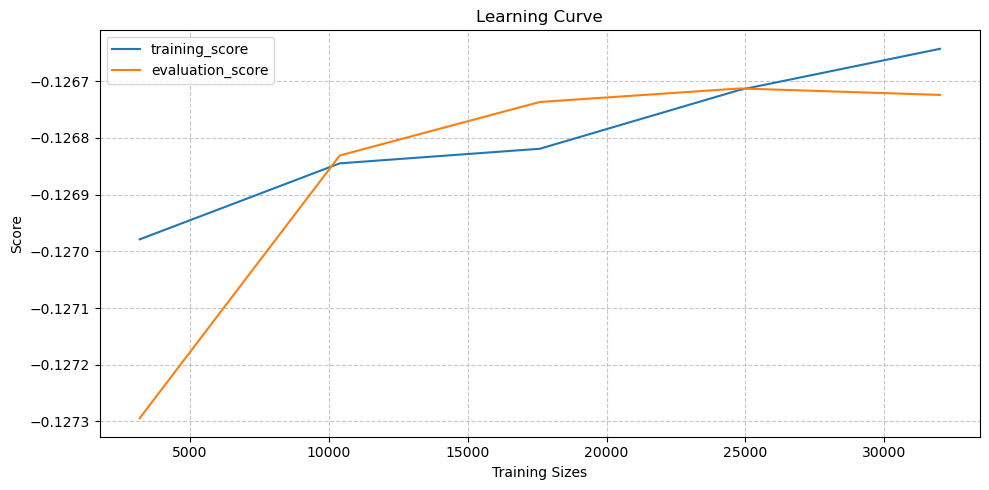

In [16]:
ax = utils.modeling.plot_learning_curve(
    estimator=lr_model,
    X_train=X_train_scaled,
    y_train=y_train,
    train_sizes=np.linspace(0.1, 1, 5),
    cv=5,
    scoring="neg_mean_absolute_error"
)

In [17]:
def importance_sign(importance):
    if importance > 0:
        return "Positive"
    else:
        return "negative"

importances = pd.DataFrame(
	data=lr_model.coef_,
    index=data["features"],
    columns=["feature_importance"]
)
importances['abs_feature_importance'] = abs(lr_model.coef_)
importances['sign'] = importances['feature_importance'].apply(importance_sign)
importances = importances.sort_values(by="abs_feature_importance")

importances

,feature_importance,abs_feature_importance,sign
tool_diversity,0.000558,0.000558,Positive
weekly_genai_hours,0.000602,0.000602,Positive
major_category_humanities,0.001096,0.001096,Positive
skill_retention_score,0.001181,0.001181,Positive
perceived_ai_dependency,-0.001355,0.001355,negative
major_category_stem,-0.001440,0.001440,negative
major_category_business,-0.001817,0.001817,negative
burnout_risk_level,-0.002196,0.002196,negative
anxiety_level_during_exams,-0.003644,0.003644,negative
major_category_medical,0.004232,0.004232,Positive


Text(0.03, 5, '(features with an importance under 0.5 are not important)')

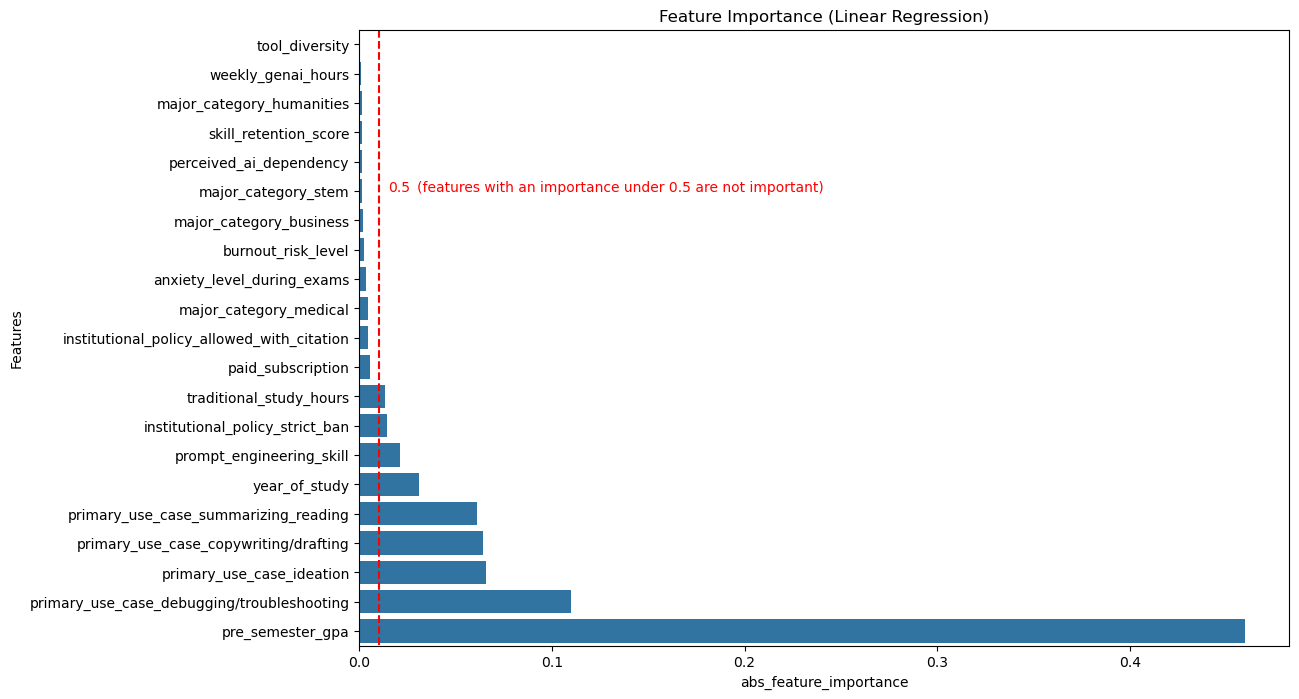

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importances,
    y=importances.index,
    x="abs_feature_importance"
)

plt.title("Feature Importance (Linear Regression)")
plt.ylabel("Features")
plt.vlines(x=0.01, ymin=-0.5, ymax=20.5, color="red", linestyle="--")
plt.ylim(20.5, -0.5)
plt.text(0.015, y=5, s="0.5", color="red")
plt.text(0.03, y=5, s="(features with an importance under 0.5 are not important)", color="red")

By looking at the feature importance plot it can be derived that these features has the most impact in the post semester GPA of a student:
- Pre Semester GPA
- Primary Use Case of AI: debugging/troubleshooting, ideation, copywriting/drafting, summarizing/drafting
- Year of Study
- Prompt Engineering Skill
- Institutional Policy: strict ban
- Traditional Study Hours

In [19]:
print("-" * 50)
print("Important Features:")
print("-" * 50)
importances[importances['abs_feature_importance'] > 0.01]

--------------------------------------------------
Important Features:
--------------------------------------------------


,feature_importance,abs_feature_importance,sign
traditional_study_hours,0.013310,0.013310,Positive
institutional_policy_strict_ban,-0.014537,0.014537,negative
prompt_engineering_skill,0.021042,0.021042,Positive
year_of_study,0.030867,0.030867,Positive
primary_use_case_summarizing_reading,0.060897,0.060897,Positive
primary_use_case_copywriting/drafting,0.064173,0.064173,Positive
primary_use_case_ideation,0.065694,0.065694,Positive
primary_use_case_debugging/troubleshooting,0.109661,0.109661,Positive
pre_semester_gpa,0.459831,0.459831,Positive


- Based-on the feature importance we can say institutional policy that strictly ban the usage of AI is more likely to have negative effect on the post semester GPA of the students.
- Primary use case of AI for debugging/troubleshooting is more likely to have more positive effect on the post semester GPA than other primary use cases like ideation, copywriting/drafting, summarizing reading, etc.

In [20]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_jobs=-1, random_state=42
)
random_forest.fit(X_train_scaled, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [21]:
utils.modeling.regression_report(random_forest, X_test_scaled, y_test)

,Metrics
Mean Squared Error,0.024564
Root Mean Squared Error,0.156729
Mean Absolute Error,0.121632
R-Square (Goodness of Fit),0.898237


In [22]:
random_forest_importances = pd.DataFrame(
	data=random_forest.feature_importances_,
    index=data["features"],
    columns=["feature_importance"]
)
random_forest_importances = random_forest_importances.sort_values(by="feature_importance")

random_forest_importances

,feature_importance
major_category_medical,0.001023
primary_use_case_summarizing_reading,0.001080
major_category_humanities,0.001214
primary_use_case_ideation,0.001233
primary_use_case_copywriting/drafting,0.001270
major_category_business,0.001319
institutional_policy_strict_ban,0.001385
major_category_stem,0.001501
institutional_policy_allowed_with_citation,0.001552
paid_subscription,0.001800


Text(0, 0.5, 'Features')

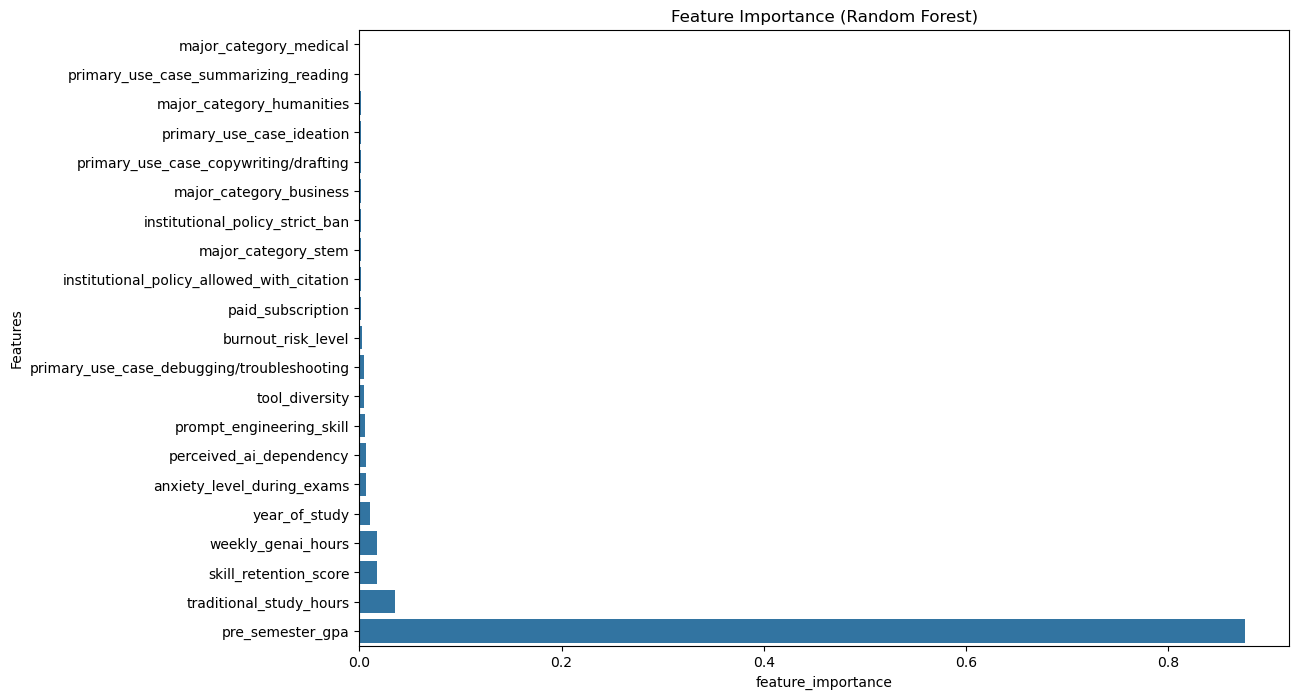

In [23]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=random_forest_importances,
    y=random_forest_importances.index,
    x="feature_importance"
)

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Features")

Based-on the feature importance of the random forest model we can derive important features like:
- Pre semester GPA
- Traditional study hours
- Skill retention score
- Weekly GenAI hours
- Year of study

These features have feature importance coefficient higher that 0.01.

In [24]:
gradient_boost = GradientBoostingRegressor(random_state=42)
gradient_boost.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [25]:
utils.modeling.regression_report(gradient_boost, X_test_scaled, y_test)

,Metrics
Mean Squared Error,0.021973
Root Mean Squared Error,0.148231
Mean Absolute Error,0.116193
R-Square (Goodness of Fit),0.908973


In [26]:
gradient_boost_importances = pd.DataFrame(
	data=gradient_boost.feature_importances_,
    index=data['features'],
    columns=["feature_importance"]
).sort_values(by="feature_importance")

gradient_boost_importances

,feature_importance
major_category_humanities,0.000000e+00
major_category_medical,0.000000e+00
major_category_business,0.000000e+00
institutional_policy_allowed_with_citation,0.000000e+00
major_category_stem,7.248305e-07
tool_diversity,1.982536e-06
perceived_ai_dependency,1.086305e-05
burnout_risk_level,2.156551e-05
anxiety_level_during_exams,6.185924e-05
primary_use_case_copywriting/drafting,1.354840e-04


Text(0, 0.5, 'Features')

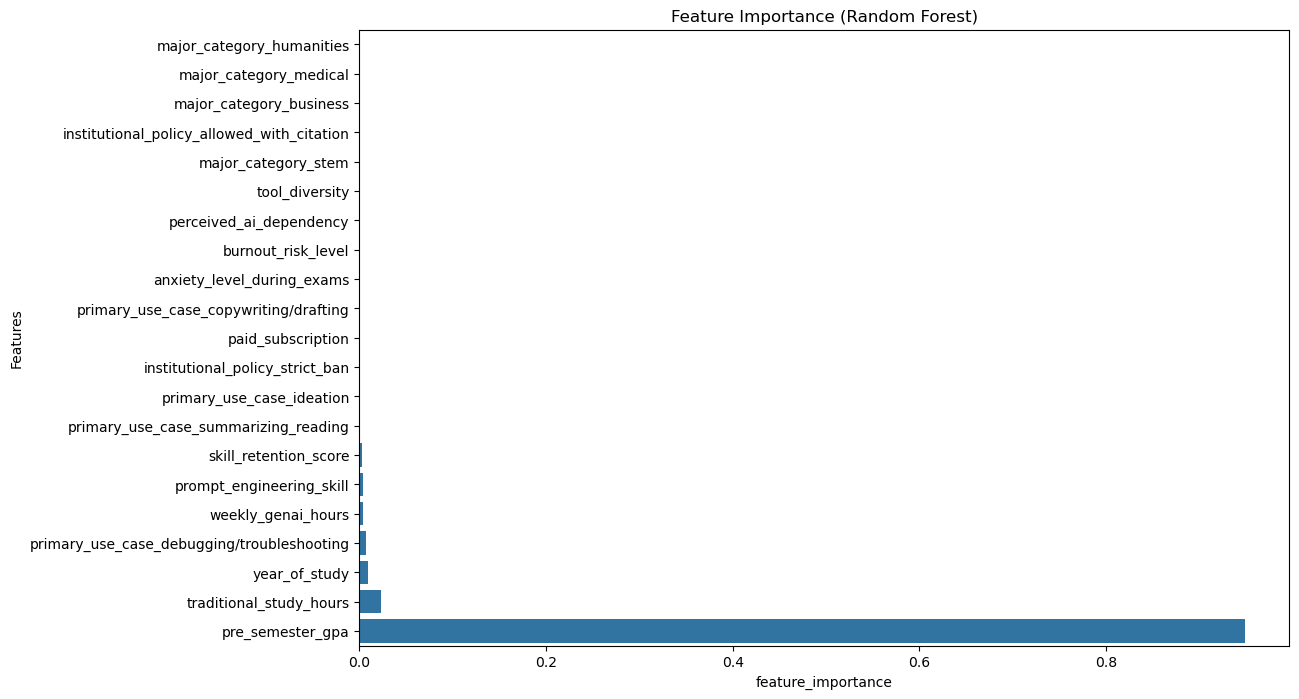

In [27]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=gradient_boost_importances,
    y=gradient_boost_importances.index,
    x="feature_importance"
)

plt.title("Feature Importance (Random Forest)")
plt.ylabel("Features")

Using Gradient Boosting Regressor we trained our best model best on the parameters and using feature importance most impactful features are:
- Pre Semester GPA
- Traditional study hours
- Year of study
- Primary use case: debugging/troubleshooting

We trained 3 different regression models on this dataset to predict the post semeste GPA of the students and now we compare different metrics to choose the best model:

In [28]:
# column_name_mapper = {
    
# }

model_evaluation_metrics = pd.concat(
    [
        utils.modeling.regression_report(
			model=lr_model, X_test=X_test_scaled, y_test=y_test
		).rename(columns={"Metrics": "linear_regression"}),
        utils.modeling.regression_report(
            model=random_forest, X_test=X_test_scaled, y_test=y_test
		).rename(columns={"Metrics": "random_forest"}),
        utils.modeling.regression_report(
            model=gradient_boost, X_test=X_test_scaled, y_test=y_test
		).rename(columns={"Metrics": "gradient_boosting"})
	],
    axis=1
)

model_evaluation_metrics

,linear_regression,random_forest,gradient_boosting
Mean Squared Error,0.025168,0.024564,0.021973
Root Mean Squared Error,0.158644,0.156729,0.148231
Mean Absolute Error,0.124621,0.121632,0.116193
R-Square (Goodness of Fit),0.895736,0.898237,0.908973


Comparing these three models we can choose Gradient Boosting Regressor as the best model based-on the evaluation metrics (lower errors and higher R-square).

By using majority voting technique we can choose three most important features based-on the models feature importances and coefficients:
1. Pre Semester GPA
2. Traditional study hours
3. Year of study

These features could be the most impactful predictors to predict the GPA of a student at the end of the semester.

Also we can say in using AI if your primary use case is debugging/troubleshootin there is a higher chance to have better post semester GPA.

In [29]:
# best model
gradient_boost

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

# cross validated scores
mse_cv = cross_validate(
    estimator=gradient_boost,
    X=X_train_scaled,
    y=y_train,
    scoring=make_scorer(mean_squared_error, greater_is_better=False),
    cv=5,
    n_jobs=-1,
    
)
rmse_cv = cross_validate(
    estimator=gradient_boost,
    X=X_train_scaled,
    y=y_train,
    scoring=make_scorer(root_mean_squared_error, greater_is_better=False),
    cv=5,
    n_jobs=-1,
    
)
mae_cv = cross_validate(
    estimator=gradient_boost,
    X=X_train_scaled,
    y=y_train,
    scoring=make_scorer(mean_absolute_error, greater_is_better=False),
    cv=5,
    n_jobs=-1,
    
)
r_square_cv = cross_validate(
    estimator=gradient_boost,
    X=X_train_scaled,
    y=y_train,
    scoring=make_scorer(r2_score),
    cv=5,
    n_jobs=-1,
    
)

In [52]:
# test scores
y_pred = gradient_boost.predict(X_test_scaled)

mse_test = mean_squared_error(y_test, y_pred)
rmse_test = root_mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
r_square_test = r2_score(y_test, y_pred)

metrics = pd.DataFrame(
    data=np.array([
        [-mse_cv['test_score'].mean(), mse_test],
        [-rmse_cv['test_score'].mean(), rmse_test],
        [-mae_cv['test_score'].mean(), mae_test],
        [r_square_cv['test_score'].mean(), r_square_test]
	]),
    index=["MSE", "RMSE", "MAE", "R-Square"],
    columns=["Train Score", "Test Score"]
)

metrics

,Train Score,Test Score
MSE,0.022967,0.021973
RMSE,0.151542,0.148231
MAE,0.118180,0.116193
R-Square,0.906902,0.908973


There is no big difference between metrics on the training and the test set so we didn't encounter overfitting.